In [2]:
import sys

print(sys.executable)

C:\Users\leoja\AppData\Roaming\jupyterlab-desktop\jlab_server\python.exe


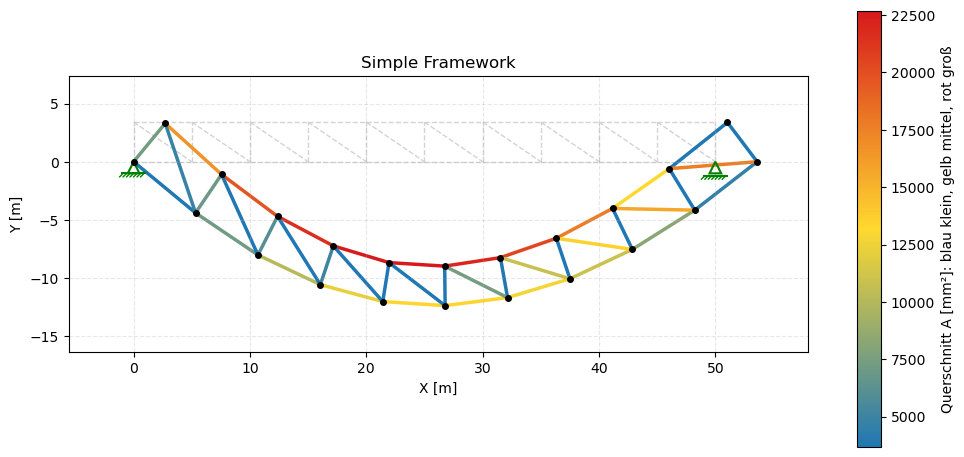

In [3]:
# ---------------------------------------------------------
# FE-Stabwerksprogramm (Aufgabe 5)
# Bearbeiter: Gabriel Pyka, Leonard Jaufmann, Martin Renner, Daniel Ryvkin
# ---------------------------------------------------------

import tkinter as tk
from tkinter import ttk
from tkinter import filedialog as fd
from tkinter import messagebox
import csv
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import numpy as np # HINZUGEFÜGT: Numerik-Bibliothek für die Matrizenrechnung
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, Normalize


class ScrollbaresTab(ttk.Frame):
    def __init__(self, parent, *args, **kwargs):
        super().__init__(parent, *args, **kwargs)
        
        # 1. Canvas und Scrollbar erstellen
        self.canvas = tk.Canvas(self, borderwidth=0, highlightthickness=0)
        self.scrollbar = ttk.Scrollbar(self, orient="vertical", command=self.canvas.yview)
        
        # 2. Der Frame, der WIRKLICH die Elemente enthält (das ist unser Ziel für Widgets)
        self.inner_frame = ttk.Frame(self.canvas)
        
        # 3. Wenn der Frame wächst, Scrollbereich des Canvas anpassen
        self.inner_frame.bind(
            "<Configure>",
            lambda e: self.canvas.configure(
                scrollregion=self.canvas.bbox("all")
            )
        )
        
        # 4. Frame ins Canvas packen
        self.canvas_window = self.canvas.create_window((0, 0), window=self.inner_frame, anchor="nw")
        self.canvas.configure(yscrollcommand=self.scrollbar.set)
        
        # 5. Layout (Canvas links, Scrollbar rechts)
        self.canvas.pack(side="left", fill="both", expand=True)
        self.scrollbar.pack(side="right", fill="y")
        
        # 6. Mausrad-Support (Nur aktiv, wenn die Maus über dem Tab ist)
        self.canvas.bind('<Enter>', self._bound_to_mousewheel)
        self.canvas.bind('<Leave>', self._unbound_to_mousewheel)
        
        # Auch anpassen, wenn sich das Fenster vergrößert
        self.canvas.bind('<Configure>', self._on_canvas_configure)

    def _on_canvas_configure(self, event):
        # Sorgt dafür, dass sich der innere Frame an die Breite des Canvas anpasst
        self.canvas.itemconfig(self.canvas_window, width=event.width)

    def _bound_to_mousewheel(self, event):
        self.canvas.bind_all("<MouseWheel>", self._on_mousewheel)
        self.canvas.bind_all("<Button-4>", self._on_mousewheel_linux)
        self.canvas.bind_all("<Button-5>", self._on_mousewheel_linux)

    def _unbound_to_mousewheel(self, event):
        self.canvas.unbind_all("<MouseWheel>")
        self.canvas.unbind_all("<Button-4>")
        self.canvas.unbind_all("<Button-5>")

    def _on_mousewheel(self, event):
        # Windows & Mac Scroll-Logik
        self.canvas.yview_scroll(int(-1*(event.delta/120)), "units")
        
    def _on_mousewheel_linux(self, event):
        # Linux Scroll-Logik
        if event.num == 4: self.canvas.yview_scroll(-1, "units")
        elif event.num == 5: self.canvas.yview_scroll(1, "units")


def initialisiere_querschnitte(system):
    anzahl_elemente = len(system.get('elemente', []))
    if anzahl_elemente == 0:
        system['element_flaechen'] = []
        return
    
    flaechen = system.get('element_flaechen', [])
    if len(flaechen) != anzahl_elemente:
        system['element_flaechen'] = [system.get('flaeche', 0.0)] * anzahl_elemente


def element_flaeche(system, index):
    initialisiere_querschnitte(system)
    return system['element_flaechen'][index]


def stablaenge_mm(system, element):
    n1_id, n2_id = element
    x1, y1 = system['knoten'][n1_id]
    x2, y2 = system['knoten'][n2_id]
    dx = (x2 - x1) * 1000
    dy = (y2 - y1) * 1000
    return np.sqrt(dx**2 + dy**2), dx, dy


def berechne_elementsteifigkeiten(system):
    """Schritt 1: Berechnet die 4x4 Elementsteifigkeitsmatrix für jeden Stab."""
    E = system['e_modul']  # in N/mm²
    initialisiere_querschnitte(system)
    
    element_matrizen = []
    
    for idx, element in enumerate(system['elemente']):
        n1_id = element[0]
        n2_id = element[1]
        A = element_flaeche(system, idx)  # in mm²
        EA = E * A                        # Steifigkeit in N
        
        # Koordinaten auslesen (sind in Metern!)
        x1, y1 = system['knoten'][n1_id]
        x2, y2 = system['knoten'][n2_id]
        
        # In Millimeter umrechnen für konsistente Einheiten (N und mm)
        dx = (x2 - x1) * 1000
        dy = (y2 - y1) * 1000
        L = np.sqrt(dx**2 + dy**2)
        
        # Winkel (Kosinus und Sinus)
        c = dx / L
        s = dy / L
        
        # Transformations- und Steifigkeitsmatrix (lokal zu global)
        k_el = (EA / L) * np.array([
            [ c*c,  c*s, -c*c, -c*s],
            [ c*s,  s*s, -c*s, -s*s],
            [-c*c, -c*s,  c*c,  c*s],
            [-c*s, -s*s,  c*s,  s*s]
        ])
        element_matrizen.append(k_el)
        
    system['element_matrizen'] = element_matrizen
    return element_matrizen


def assembliere_gesamtsteifigkeit(system):
    """Schritt 2: Assembliert die globale Steifigkeitsmatrix."""
    num_nodes = len(system['knoten'])
    # Leere Gesamtmatrix erstellen (2 Freiheitsgrade pro Knoten)
    K_gesamt = np.zeros((num_nodes * 2, num_nodes * 2))
    
    for idx, element in enumerate(system['elemente']):
        n1_id = element[0]
        n2_id = element[1]
        k_el = system['element_matrizen'][idx]
        
        # Mapping: Knoten-ID 1 bedeutet Freiheitsgrade 0 (X) und 1 (Y)
        dofs = [
            (n1_id - 1) * 2, 
            (n1_id - 1) * 2 + 1, 
            (n2_id - 1) * 2, 
            (n2_id - 1) * 2 + 1
        ]
        
        # Matrix-Superposition (Aufaddieren)
        for i in range(4):
            for j in range(4):
                K_gesamt[dofs[i], dofs[j]] += k_el[i, j]
                
    system['K_gesamt'] = K_gesamt
    return K_gesamt


def loese_gleichungssystem(system):
    """Schritt 3: Baut Lastvektor auf, streicht Lager-DOFs und löst nach Verschiebungen u."""
    num_nodes = len(system['knoten'])
    F_gesamt = np.zeros(num_nodes * 2)
    
    # 1. Lastvektor befüllen (Kräfte in N)
    for last in system.get('lasten', []):
        n_id, fx, fy = last
        F_gesamt[(n_id - 1) * 2] += fx
        F_gesamt[(n_id - 1) * 2 + 1] += fy
        
    # 2. Blockierte Freiheitsgrade (Lager) identifizieren
    fixed_dofs = []
    for lager in system.get('lager', []):
        n_id, fix_x, fix_y = lager
        if fix_x == 1: fixed_dofs.append((n_id - 1) * 2)
        if fix_y == 1: fixed_dofs.append((n_id - 1) * 2 + 1)
        
    # Aktive Freiheitsgrade ermitteln
    active_dofs = [i for i in range(num_nodes * 2) if i not in fixed_dofs]
    
    # 3. Gleichungssystem reduzieren (Randbedingungen einarbeiten)
    K_red = system['K_gesamt'][np.ix_(active_dofs, active_dofs)]
    F_red = F_gesamt[active_dofs]
    
    # 4. Lösen (Direktes Verfahren nach Cholesky/Gauß)
    U_red = np.linalg.solve(K_red, F_red)
    
    # 5. Gesamten Verschiebungsvektor wieder zusammensetzen
    U_gesamt = np.zeros(num_nodes * 2)
    U_gesamt[active_dofs] = U_red
    
    system['verschiebungen'] = U_gesamt
    return U_gesamt

def berechne_stabkraefte(system):
    bar_forces = []
    bar_stresses = []
    bar_utilization = []
    bar_stability_utilization = []
    U = system['verschiebungen']
    initialisiere_querschnitte(system)
    allowable_stress = system['streckgrenze'] / max(system.get('sicherheit', 1.0), 1e-12)
    
    for idx, element in enumerate(system.get('elemente', [])):
        n1_id, n2_id = element
        x1, y1 = system['knoten'][n1_id]
        x2, y2 = system['knoten'][n2_id]
        A = element_flaeche(system, idx)
        EA = system['e_modul'] * A
        
        dx = (x2 - x1) * 1000
        dy = (y2 - y1) * 1000
        L = np.sqrt(dx**2 + dy**2)
        c = dx / L
        s = dy / L
        
        u1x = U[(n1_id - 1) * 2]
        u1y = U[(n1_id - 1) * 2 + 1]
        u2x = U[(n2_id - 1) * 2]
        u2y = U[(n2_id - 1) * 2 + 1]
        
        force_n = (EA / L) * ((u2x - u1x) * c + (u2y - u1y) * s)
        stress = force_n / A
        utilization = abs(stress) / allowable_stress if allowable_stress > 0 else 0.0
        if force_n < 0:
            traegheitsmoment = A**2 / (4 * np.pi)
            n_krit = (np.pi**2 * system['e_modul'] * traegheitsmoment) / (L**2)
            stability_utilization = (abs(force_n) * system.get('sicherheit', 1.0)) / n_krit if n_krit > 0 else 0.0
        else:
            stability_utilization = 0.0
        
        bar_forces.append(force_n / 1000.0)
        bar_stresses.append(stress)
        bar_utilization.append(utilization)
        bar_stability_utilization.append(stability_utilization)
    system['bar_forces'] = bar_forces
    system['bar_stresses'] = bar_stresses
    system['bar_utilization'] = bar_utilization
    system['bar_stability_utilization'] = bar_stability_utilization

def fuehre_fem_berechnung_aus(system):
    berechne_elementsteifigkeiten(system)
    assembliere_gesamtsteifigkeit(system)
    loese_gleichungssystem(system)
    berechne_stabkraefte(system)


def starte_berechnung(system, status_label, ax, canvas, tab_elemente=None):
    if not system.get('knoten'):
        status_label.config(text="Status: Fehler! Bitte zuerst eine Datei laden.")
        return
    if not system.get('elemente'):
        status_label.config(text="Status: Fehler! Keine Stäbe vorhanden.")
        return
        
    try:
        fuehre_fem_berechnung_aus(system)
        system['berechnet'] = True
        system['zeige_querschnitte'] = False
        if tab_elemente is not None:
            aktualisiere_elemente_tab(tab_elemente, system)
        aktualisiere_plot(system, ax, canvas)
        
        max_u = np.max(np.abs(system['verschiebungen']))
        max_util = max(system.get('bar_utilization', [0.0])) * 100
        status_label.config(text=f"Status: FEM-Berechnung erfolgreich! Max. Verschiebung: {max_u:.2f} mm, max. Ausnutzung: {max_util:.1f}%. Werte stehen im Tab Elemente.")
    except Exception as e:
        status_label.config(text=f"Status: Rechenfehler ({str(e)})") 


def erforderliche_flaeche(system, element, force_n):
    sicherheit = system.get('sicherheit', 1.0)
    sigma_zul = system['streckgrenze'] / max(sicherheit, 1e-12)
    laenge, _, _ = stablaenge_mm(system, element)
    area_stress = abs(force_n) / sigma_zul if sigma_zul > 0 else 0.0
    area_buckling = 0.0
    
    if force_n < 0:
        area_buckling = np.sqrt((4 * laenge**2 * abs(force_n) * sicherheit) / (np.pi * system['e_modul']))
    
    min_area = max(system.get('flaeche', 0.0) * 0.05, 1.0)
    return max(area_stress, area_buckling, min_area) * 1.05


def system_volumenkennwert(system, flaechen):
    volumen = 0.0
    for area, element in zip(flaechen, system.get('elemente', [])):
        laenge, _, _ = stablaenge_mm(system, element)
        volumen += area * laenge
    return volumen


def optimierungsbericht(system, original, optimiert, ersparnis, min_area, max_area):
    max_u = max(abs(v) for v in system.get('verschiebungen', [0.0]))
    max_spannung = max(system.get('bar_utilization', [0.0])) * 100
    max_knicken = max(system.get('bar_stability_utilization', [0.0])) * 100
    kritisch_spannung = int(np.argmax(system.get('bar_utilization', [0.0]))) + 1
    kritisch_knicken = int(np.argmax(system.get('bar_stability_utilization', [0.0]))) + 1
    
    return (
        "Optimierung der Querschnittsflächen abgeschlossen\n\n"
        f"Ausgangsfläche je Stab: {system.get('querschnitt_ausgangsflaeche', system.get('flaeche', 0.0)):.0f} mm²\n"
        f"Kleinster optimierter Querschnitt: {min_area:.0f} mm²\n"
        f"Größter optimierter Querschnitt: {max_area:.0f} mm²\n"
        f"Volumenkennwert vorher: {original:,.0f} mm³\n"
        f"Volumenkennwert optimiert: {optimiert:,.0f} mm³\n"
        f"Materialersparnis: {ersparnis:.1f} %\n\n"
        f"Maximale Verschiebung: {max_u:.2f} mm\n"
        f"Maximale Spannungsausnutzung: {max_spannung:.1f} % bei Stab {kritisch_spannung}\n"
        f"Maximale Knickausnutzung: {max_knicken:.1f} % bei Stab {kritisch_knicken}"
    )


def optimiere_querschnitte(system, status_label, ax, canvas, tab_elemente):
    if not system.get('knoten'):
        status_label.config(text="Status: Fehler! Bitte zuerst eine Datei laden.")
        return
    if not system.get('elemente'):
        status_label.config(text="Status: Fehler! Keine Stäbe vorhanden.")
        return
    
    try:
        start_area = system.get('flaeche', 0.0)
        anzahl_elemente = len(system.get('elemente', []))
        system['element_flaechen'] = [start_area] * anzahl_elemente
        system['querschnitt_ausgangsflaeche'] = start_area
        
        for _ in range(30):
            alte_flaechen = system['element_flaechen'][:]
            fuehre_fem_berechnung_aus(system)
            
            neue_flaechen = []
            for idx, element in enumerate(system['elemente']):
                force_n = system['bar_forces'][idx] * 1000
                neue_flaechen.append(erforderliche_flaeche(system, element, force_n))
            
            system['element_flaechen'] = neue_flaechen
            groesste_aenderung = max(
                abs(neu - alt) / max(alt, 1.0)
                for neu, alt in zip(neue_flaechen, alte_flaechen)
            )
            if groesste_aenderung < 0.001:
                break
        
        fuehre_fem_berechnung_aus(system)
        system['berechnet'] = True
        system['zeige_querschnitte'] = True
        system['querschnitte_optimiert'] = True
        aktualisiere_elemente_tab(tab_elemente, system)
        aktualisiere_plot(system, ax, canvas)
        
        original = system_volumenkennwert(system, [start_area] * anzahl_elemente)
        optimiert = system_volumenkennwert(system, system['element_flaechen'])
        ersparnis = (1 - optimiert / original) * 100 if original > 0 else 0.0
        min_area = min(system['element_flaechen']) if system['element_flaechen'] else 0.0
        max_area = max(system['element_flaechen']) if system['element_flaechen'] else 0.0
        status_label.config(
            text=f"Status: Querschnitte optimiert. Materialersparnis: {ersparnis:.1f}%, A min/max: {min_area:.0f}/{max_area:.0f} mm²"
        )
        messagebox.showinfo(
            "Ergebnis der Querschnittsoptimierung",
            optimierungsbericht(system, original, optimiert, ersparnis, min_area, max_area)
        )
    except Exception as e:
        status_label.config(text=f"Status: Optimierungsfehler ({str(e)})")


def sichere_aktion(status_label, aktion, beschreibung):
    try:
        aktion()
    except Exception as e:
        meldung = f"{beschreibung}: {str(e)}"
        status_label.config(text=f"Status: Fehler! {meldung}")
        messagebox.showerror("Programmfehler", meldung)


def datei_waehlen_und_laden(system, entries, ax, canvas, status_label, tab_knoten, entries_knoten, tab_elemente, tab_lasten, entries_lasten, tab_lager):
    filename = fd.askopenfilename(filetypes=[('Textdateien', '*.txt'), ('Alle Dateien', '*.*')])
    if not filename:
        status_label.config(text="Status: Auswahl abgebrochen.")
        return
    
    try:
        with open(filename, 'r', encoding='utf-8') as file:
            lines = file.readlines()
    except Exception as e:
        status_label.config(text=f"Status: Fehler beim Lesen der Datei ({str(e)})")
        return
    system['berechnet'] = False
    system['zeige_querschnitte'] = False
    system['querschnitte_optimiert'] = False
    data = [line.split('#')[0].strip() for line in lines if line.split('#')[0].strip()]
    
    try:
        system['name'] = data[0]
        system['e_modul'] = float(data[1])
        system['streckgrenze'] = float(data[2])
        system['sicherheit'] = float(data[3])
        system['flaeche'] = float(data[4])
        
        current_idx = 5
        num_nodes = int(data[current_idx])
        system['knoten'] = {}
        current_idx += 1
        for i in range(1, num_nodes + 1):
            coords = data[current_idx].split()
            system['knoten'][i] = [float(coords[0]), float(coords[1])]
            current_idx += 1
            
        num_elements = int(data[current_idx])
        system['elemente'] = []
        current_idx += 1
        for _ in range(num_elements):
            nodes = data[current_idx].split()
            system['elemente'].append([int(nodes[0]), int(nodes[1])])
            current_idx += 1
        system['element_flaechen'] = [system['flaeche']] * len(system['elemente'])
        system['querschnitt_ausgangsflaeche'] = system['flaeche']
            
        num_loads = int(data[current_idx])
        system['lasten'] = []
        current_idx += 1
        for _ in range(num_loads):
            load_data = data[current_idx].split()
            system['lasten'].append([int(load_data[0]), float(load_data[1]), float(load_data[2])])
            current_idx += 1
            
        num_supports = int(data[current_idx])
        system['lager'] = []
        current_idx += 1
        for _ in range(num_supports):
            sup_data = data[current_idx].split()
            system['lager'].append([int(sup_data[0]), int(sup_data[1]), int(sup_data[2])])
            current_idx += 1

        entries['name'].delete(0, tk.END)
        entries['name'].insert(0, str(system['name']))
        entries['e_modul'].delete(0, tk.END)
        entries['e_modul'].insert(0, str(system['e_modul']))
        entries['streckgrenze'].delete(0, tk.END)
        entries['streckgrenze'].insert(0, str(system['streckgrenze']))
        entries['sicherheit'].delete(0, tk.END)
        entries['sicherheit'].insert(0, str(system['sicherheit']))
        entries['flaeche'].delete(0, tk.END)
        entries['flaeche'].insert(0, str(system['flaeche']))

        aktualisiere_knoten_tab(tab_knoten, system, entries_knoten, ax, canvas, status_label, tab_elemente, tab_lager)
        aktualisiere_elemente_tab(tab_elemente, system)
        aktualisiere_lasten_tab(tab_lasten, system, entries_lasten, ax, canvas, status_label)
        aktualisiere_lager_tab(tab_lager, system)
        aktualisiere_plot(system, ax, canvas)
        status_label.config(text=f"Status: Datei erfolgreich geladen ({filename})")


    except Exception as e:
        status_label.config(text=f"Status: Fehler beim Parsen der Datei ({str(e)})")


def berechne_plot_grenzen(system, ueberhoehung):
    x_vals = []
    y_vals = []
    
    for n_id, coords in system.get('knoten', {}).items():
        x_vals.append(coords[0])
        y_vals.append(coords[1])
        
        if system.get('berechnet', False) and 'verschiebungen' in system:
            u = system['verschiebungen']
            x_vals.append(coords[0] + (u[(n_id - 1) * 2] / 1000) * ueberhoehung)
            y_vals.append(coords[1] + (u[(n_id - 1) * 2 + 1] / 1000) * ueberhoehung)
    
    for lager in system.get('lager', []):
        n_id, _, _ = lager
        if n_id in system.get('knoten', {}):
            kx, ky = system['knoten'][n_id]
            x_vals.extend([kx - 1.2, kx + 1.2])
            y_vals.extend([ky - 1.6, ky])
    
    if not x_vals or not y_vals:
        return None
    
    min_x, max_x = min(x_vals), max(x_vals)
    min_y, max_y = min(y_vals), max(y_vals)
    breite = max(max_x - min_x, 1.0)
    hoehe = max(max_y - min_y, 1.0)
    rand_x = max(4.0, breite * 0.08)
    rand_y = max(4.0, hoehe * 0.12)
    
    return min_x - rand_x, max_x + rand_x, min_y - rand_y, max_y + rand_y


def aktualisiere_plot(system, ax, canvas):
    fig = ax.figure
    for extra_ax in fig.axes[1:]:
        fig.delaxes(extra_ax)
    ax.clear()
    ueberhoehung = 100
    if system.get('berechnet', False):
        ax.set_position([0.07, 0.12, 0.76, 0.78])
    else:
        ax.set_position([0.07, 0.12, 0.88, 0.78])
    ax.set_title(system.get('name', 'Fachwerk'))
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.grid(True, linestyle='--', alpha=0.3)
    
    stress_cmap = LinearSegmentedColormap.from_list(
        "belastung_blau_gelb_rot",
        [(0.0, "#1f77b4"), (0.5, "#ffd92f"), (1.0, "#d7191c")]
    )
    norm = Normalize(vmin=0.0, vmax=1.0)
    area_cmap = LinearSegmentedColormap.from_list(
        "querschnitt_blau_gelb_rot",
        [(0.0, "#1f77b4"), (0.5, "#ffd92f"), (1.0, "#d7191c")]
    )
    flaechen = system.get('element_flaechen', [])
    if flaechen:
        area_norm = Normalize(vmin=min(flaechen), vmax=max(flaechen) if max(flaechen) > min(flaechen) else min(flaechen) + 1)
    else:
        area_norm = Normalize(vmin=0.0, vmax=1.0)
    
    # 1. Stäbe zeichnen (verformt falls berechnet)
    for idx, elem in enumerate(system.get('elemente', [])):
        n1 = system['knoten'][elem[0]]
        n2 = system['knoten'][elem[1]]
        
        if system.get('berechnet', False):
            u = system.get('verschiebungen', np.zeros(len(system['knoten'])*2))
            x1 = n1[0] + (u[(elem[0]-1)*2] / 1000) * ueberhoehung
            y1 = n1[1] + (u[(elem[0]-1)*2+1] / 1000) * ueberhoehung
            x2 = n2[0] + (u[(elem[1]-1)*2] / 1000) * ueberhoehung
            y2 = n2[1] + (u[(elem[1]-1)*2+1] / 1000) * ueberhoehung
            
            if system.get('zeige_querschnitte', False):
                color = area_cmap(area_norm(element_flaeche(system, idx)))
            else:
                utilization = system.get('bar_utilization', [0.0] * len(system.get('elemente', [])))[idx]
                color = stress_cmap(norm(min(utilization, 1.0)))
            
            # Gestrichelt = Unverformt, Durchgezogen = Verformt
            ax.plot([n1[0], n2[0]], [n1[1], n2[1]], color='lightgray', linestyle='--', lw=1, zorder=0)
            ax.plot([x1, x2], [y1, y2], color=color, lw=2.5, zorder=1)
            
        else:
            ax.plot([n1[0], n2[0]], [n1[1], n2[1]], 'b-', lw=1.5, zorder=1)

    # 2. Knoten zeichnen
    for n_id, coords in system.get('knoten', {}).items():
        if system.get('berechnet', False):
            x = coords[0] + (system['verschiebungen'][(n_id-1)*2] / 1000) * 100
            y = coords[1] + (system['verschiebungen'][(n_id-1)*2+1] / 1000) * 100
        else:
            x, y = coords[0], coords[1]
            
        ax.plot(x, y, 'ko', markersize=4, zorder=3)
        if system.get('zeige_nummern', False):
            ax.text(x + 0.2, y + 0.2, str(n_id), fontsize=8, color='black', zorder=4)

    # 3. Äußere Lasten als separate Pfeile (Spitze zeigt auf Knoten)
    if not system.get('berechnet', False): # Nur im unverformten Zustand anzeigen
        # Größte Kraft für Normierung finden
        max_f = max([abs(fx) for _, fx, fy in system.get('lasten', [])] + 
                    [abs(fy) for _, fx, fy in system.get('lasten', [])] + [1])
        ref_len = 3.0 # Länge des Pfeils für die Maximalkraft
        
        for last in system.get('lasten', []):
            n_id, fx, fy = last
            if n_id not in system['knoten']: continue
            kx, ky = system['knoten'][n_id]
            
            # Fx-Komponente
            if fx != 0:
                length = (abs(fx) / max_f) * ref_len
                start_x = kx - length if fx > 0 else kx + length
                ax.annotate('', xy=(kx, ky), xytext=(start_x, ky),
                            arrowprops=dict(arrowstyle='->', color='red', lw=1.5, mutation_scale=15), zorder=4)
                ax.text(start_x, ky + 0.3, f"{fx/1000:.1f} kN", color='red', fontsize=8, ha='center')
                
            # Fy-Komponente
            if fy != 0:
                length = (abs(fy) / max_f) * ref_len
                start_y = ky + length if fy < 0 else ky - length
                ax.annotate('', xy=(kx, ky), xytext=(kx, start_y),
                            arrowprops=dict(arrowstyle='->', color='red', lw=1.5, mutation_scale=15), zorder=4)
                ax.text(kx + 0.3, start_y, f"{fy/1000:.1f} kN", color='red', fontsize=8, va='center')

    # 4. Exakte Statik-Symbole für die Lager
    for lager in system.get('lager', []):
        n_id, fix_x, fix_y = lager
        if n_id not in system['knoten']: continue
        kx, ky = system['knoten'][n_id]
        
        w = 1.0  # Breite des Dreiecks
        h = 1.0  # Höhe des Dreiecks
        
        if fix_x == 1 and fix_y == 1: # Festlager
            # Dreieck zeichnen
            triangle = patches.Polygon([[kx, ky], [kx-w/2, ky-h], [kx+w/2, ky-h]], 
                                       closed=True, fill=False, edgecolor='green', lw=1.5, zorder=2)
            ax.add_patch(triangle)
            ax.plot([kx-w, kx+w], [ky-h, ky-h], 'g-', lw=1.5) # Bodenlinie
            for i in np.linspace(kx-w+0.1, kx+w-0.1, 7): # Schraffur
                ax.plot([i, i-0.3], [ky-h, ky-h-0.3], 'g-', lw=1)
                
        elif fix_y == 1: # Loslager
            # Dreieck zeichnen
            triangle = patches.Polygon([[kx, ky], [kx-w/2, ky-h], [kx+w/2, ky-h]], 
                                       closed=True, fill=False, edgecolor='green', lw=1.5, zorder=2)
            ax.add_patch(triangle)
            ax.plot([kx-w, kx+w], [ky-h-0.2, ky-h-0.2], 'g-', lw=1.5) # Bodenlinie mit Spalt
            for i in np.linspace(kx-w+0.1, kx+w-0.1, 7): # Schraffur
                ax.plot([i, i-0.3], [ky-h-0.2, ky-h-0.5], 'g-', lw=1)

    ax.set_aspect('equal', adjustable='box')
    if system.get('berechnet', False):
        if system.get('zeige_querschnitte', False):
            sm = plt.cm.ScalarMappable(cmap=area_cmap, norm=area_norm)
        else:
            sm = plt.cm.ScalarMappable(cmap=stress_cmap, norm=norm)
        sm.set_array([])
        cax = fig.add_axes([0.88, 0.20, 0.025, 0.58])
        cbar = fig.colorbar(sm, cax=cax)
        if system.get('zeige_querschnitte', False):
            cbar.set_label('Querschnitt A [mm²]: blau klein, gelb mittel, rot groß')
        else:
            cbar.set_label('Ausnutzung: blau niedrig, gelb mittel, rot hoch')
    
    if system.get('knoten'):
        grenzen = berechne_plot_grenzen(system, ueberhoehung)
        if grenzen is not None:
            min_x, max_x, min_y, max_y = grenzen
            ax.set_xlim(min_x, max_x)
            ax.set_ylim(min_y, max_y)
    
    canvas.draw()

def parameter_uebernehmen(entries, system, ax, canvas, status_label):
    try:
        system['name'] = entries['name'].get()
        system['e_modul'] = float(entries['e_modul'].get())
        system['streckgrenze'] = float(entries['streckgrenze'].get())
        system['sicherheit'] = float(entries['sicherheit'].get())
        system['flaeche'] = float(entries['flaeche'].get())
        system['element_flaechen'] = [system['flaeche']] * len(system.get('elemente', []))
        system['querschnitt_ausgangsflaeche'] = system['flaeche']
        system['querschnitte_optimiert'] = False
        system['zeige_querschnitte'] = False
        aktualisiere_plot(system, ax, canvas)
        status_label.config(text="Status: Parameter manuell aktualisiert.")
    except ValueError:
        status_label.config(text="Status: Fehler! Bitte gültige Zahlenwerte eingeben.")

def toggle_nummern(system, ax, canvas, status_label):
    anzahl_elemente = len(system.get('elemente', []))
    if anzahl_elemente == 0:
        status_label.config(text="Status: Fehler! Kein System geladen.")
        return
    if anzahl_elemente > 80:
        status_label.config(text=f"Status: Fehler! Anzeige nicht sinnvoll (Zu viele Stäbe: {anzahl_elemente}).")
        return
    system['zeige_nummern'] = not system.get('zeige_nummern', False)
    aktualisiere_plot(system, ax, canvas)
    
def knoten_uebernehmen(entries_knoten, system, ax, canvas, status_label, tab_elemente=None, tab_lager=None):
    """Liest die geänderten X- und Y-Werte aus dem GUI-Tab und aktualisiert das System."""
    try:
        for n_id, widgets in entries_knoten.items():
            system['knoten'][n_id] = [float(widgets['x'].get()), float(widgets['y'].get())]
        if tab_elemente is not None:
            aktualisiere_elemente_tab(tab_elemente, system)
        if tab_lager is not None:
            aktualisiere_lager_tab(tab_lager, system)
        aktualisiere_plot(system, ax, canvas)
        status_label.config(text="Status: Knotenkoordinaten erfolgreich aktualisiert.")
    except ValueError:
        status_label.config(text="Status: Fehler! Bitte nur gültige Zahlenwerte für Knoten eingeben.")

def aktualisiere_knoten_tab(tab_knoten, system, entries_knoten, ax, canvas, status_label, tab_elemente=None, tab_lager=None):
    for widget in tab_knoten.winfo_children(): widget.destroy()
    entries_knoten.clear() 
    if not system.get('knoten'):
        tk.Label(tab_knoten, text="Bitte zuerst eine Datei laden.").pack(pady=20)
        return
    tk.Label(tab_knoten, text="Knoten-ID", font=('Helvetica', 10, 'bold')).grid(row=0, column=0, padx=5, pady=5)
    tk.Label(tab_knoten, text="X [m]", font=('Helvetica', 10, 'bold')).grid(row=0, column=1, padx=5, pady=5)
    tk.Label(tab_knoten, text="Y [m]", font=('Helvetica', 10, 'bold')).grid(row=0, column=2, padx=5, pady=5)
    for i, (n_id, coords) in enumerate(system['knoten'].items()):
        row_idx = i + 1 
        tk.Label(tab_knoten, text=f"Knoten {n_id}:").grid(row=row_idx, column=0, sticky="w", padx=5, pady=2)
        ent_x, ent_y = tk.Entry(tab_knoten, width=10), tk.Entry(tab_knoten, width=10)
        ent_x.insert(0, str(coords[0])); ent_x.grid(row=row_idx, column=1, padx=5, pady=2)
        ent_y.insert(0, str(coords[1])); ent_y.grid(row=row_idx, column=2, padx=5, pady=2)
        entries_knoten[n_id] = {'x': ent_x, 'y': ent_y}

    # NEU: Button zum Übernehmen der Werte ganz unten im Tab platzieren
    tk.Button(tab_knoten, text="Knoten übernehmen", bg="lightgreen", font=('Helvetica', 9, 'bold'),
              command=lambda: knoten_uebernehmen(entries_knoten, system, ax, canvas, status_label, tab_elemente, tab_lager)
             ).grid(row=len(system['knoten']) + 1, column=0, columnspan=3, pady=15)

def elemente_tabelle_daten(system):
    headers = ["Stab", "Startknoten", "Endknoten", "Laenge [m]", "Winkel [deg]", "A [mm2]"]
    if system.get('berechnet'):
        headers.extend([
            "Sicherheitsfaktor",
            "Streckgrenze [N/mm2]",
            "sigma_zul [N/mm2]",
            "N [kN]",
            "sigma [N/mm2]",
            "Spannung inkl. Sicherheit [%]",
            "Knicken inkl. Sicherheit [%]",
            "Gesamt-Ausnutzung [%]",
            "Reserve bis 100 [%]"
        ])
    
    initialisiere_querschnitte(system)
    rows = []
    sigma_zul = system.get('streckgrenze', 0.0) / max(system.get('sicherheit', 1.0), 1e-12)
    
    for row, (n1_id, n2_id) in enumerate(system['elemente'], start=1):
        idx = row - 1
        x1, y1 = system['knoten'][n1_id]
        x2, y2 = system['knoten'][n2_id]
        dx = x2 - x1
        dy = y2 - y1
        laenge = np.sqrt(dx**2 + dy**2)
        winkel = np.degrees(np.arctan2(dy, dx))
        werte = [row, n1_id, n2_id, f"{laenge:.3f}", f"{winkel:.1f}", f"{element_flaeche(system, idx):.0f}"]
        
        if system.get('berechnet'):
            spannung_ausnutzung = system.get('bar_utilization', [0.0] * len(system['elemente']))[idx] * 100
            knick_ausnutzung = system.get('bar_stability_utilization', [0.0] * len(system['elemente']))[idx] * 100
            gesamt_ausnutzung = max(spannung_ausnutzung, knick_ausnutzung)
            werte.extend([
                f"{system.get('sicherheit', 1.0):.2f}",
                f"{system.get('streckgrenze', 0.0):.1f}",
                f"{sigma_zul:.1f}",
                f"{system.get('bar_forces', [0.0] * len(system['elemente']))[idx]:.1f}",
                f"{system.get('bar_stresses', [0.0] * len(system['elemente']))[idx]:.2f}",
                f"{spannung_ausnutzung:.1f}",
                f"{knick_ausnutzung:.1f}",
                f"{gesamt_ausnutzung:.1f}",
                f"{100 - gesamt_ausnutzung:.1f}",
            ])
        rows.append(werte)
    
    return headers, rows


def exportiere_elemente_tabelle(system):
    if not system.get('elemente'):
        messagebox.showwarning("Export nicht möglich", "Bitte zuerst eine Datei laden.")
        return
    
    filename = fd.asksaveasfilename(
        defaultextension=".csv",
        filetypes=[("CSV-Datei", "*.csv"), ("Alle Dateien", "*.*")],
        initialfile="elemente_tabelle.csv"
    )
    if not filename:
        return
    
    headers, rows = elemente_tabelle_daten(system)
    with open(filename, "w", newline="", encoding="utf-8-sig") as file:
        writer = csv.writer(file, delimiter=";")
        writer.writerow(headers)
        writer.writerows(rows)
    
    messagebox.showinfo("Export abgeschlossen", f"Elementtabelle wurde gespeichert:\n{filename}")


def aktualisiere_elemente_tab(tab_elemente, system):
    """Zeigt alle Staebe aus der Strukturdatei mit Geometriedaten an."""
    for widget in tab_elemente.winfo_children():
        widget.destroy()
        
    if not system.get('elemente'):
        tk.Label(tab_elemente, text="Bitte zuerst eine Datei laden.").pack(pady=20)
        return
    
    if system.get('berechnet'):
        hinweis = (
            f"Ausnutzung inkl. Sicherheitsfaktor: Sicherheit = {system.get('sicherheit', 1.0):.2f}, "
            f"zul. Spannung = {system.get('streckgrenze', 0.0) / max(system.get('sicherheit', 1.0), 1e-12):.1f} N/mm²"
        )
    else:
        hinweis = f"Sicherheitsfaktor aus der Eingabe: {system.get('sicherheit', 1.0):.2f}"
    tk.Label(tab_elemente, text=hinweis, font=('Helvetica', 9, 'bold'), anchor="w").grid(row=0, column=0, columnspan=12, sticky="w", padx=5, pady=(5, 10))
    
    tk.Button(
        tab_elemente,
        text="Elementtabelle exportieren (CSV)",
        bg="lightgray",
        command=lambda: exportiere_elemente_tabelle(system)
    ).grid(row=1, column=0, columnspan=4, sticky="w", padx=5, pady=(0, 10))
    
    headers, rows = elemente_tabelle_daten(system)
    anzeigen_headers = headers
    anzeigen_rows = rows
    for col, text in enumerate(anzeigen_headers):
        tk.Label(tab_elemente, text=text, font=('Helvetica', 10, 'bold')).grid(row=2, column=col, padx=5, pady=5)
        
    for row_idx, werte in enumerate(anzeigen_rows, start=3):
        for col, wert in enumerate(werte):
            tk.Label(tab_elemente, text=str(wert)).grid(row=row_idx, column=col, padx=5, pady=2)

def lagertyp_bestimmen(fix_x, fix_y):
    if fix_x == 1 and fix_y == 1:
        return "Festlager"
    if fix_x == 0 and fix_y == 1:
        return "Loslager"
    if fix_x == 1 and fix_y == 0:
        return "Horizontal geführt"
    return "frei"

def aktualisiere_lager_tab(tab_lager, system):
    """Zeigt alle Lagerbedingungen aus der Strukturdatei an."""
    for widget in tab_lager.winfo_children():
        widget.destroy()
        
    if not system.get('lager'):
        tk.Label(tab_lager, text="Bitte zuerst eine Datei laden.").pack(pady=20)
        return
    
    headers = ["Lager", "Knoten", "X fest", "Y fest", "Lagertyp", "X [m]", "Y [m]"]
    for col, text in enumerate(headers):
        tk.Label(tab_lager, text=text, font=('Helvetica', 10, 'bold')).grid(row=0, column=col, padx=5, pady=5)
    
    for row, (n_id, fix_x, fix_y) in enumerate(system['lager'], start=1):
        x, y = system['knoten'].get(n_id, ["-", "-"])
        werte = [
            row,
            n_id,
            "ja" if fix_x == 1 else "nein",
            "ja" if fix_y == 1 else "nein",
            lagertyp_bestimmen(fix_x, fix_y),
            x,
            y
        ]
        
        for col, wert in enumerate(werte):
            tk.Label(tab_lager, text=str(wert)).grid(row=row, column=col, padx=5, pady=2)

def last_loeschen(index, system, tab_lasten, entries_lasten, ax, canvas, status_label):
    """Löscht eine Last anhand ihres Index und baut den Tab neu auf."""
    if 0 <= index < len(system.get('lasten', [])):
        system['lasten'].pop(index)
        aktualisiere_lasten_tab(tab_lasten, system, entries_lasten, ax, canvas, status_label)
        aktualisiere_plot(system, ax, canvas)
        status_label.config(text="Status: Last erfolgreich entfernt.")

def lasten_uebernehmen(entries_lasten, system, ax, canvas, status_label):
    """Speichert die eingegebenen Lasten aus der GUI im System ab (fehlertolerant)."""
    try:
        neue_lasten = []
        for widgets in entries_lasten:
            # Werte auslesen, Kommas durch Punkte ersetzen und Leerzeichen entfernen
            node_str = widgets['node'].get().strip()
            fx_str = widgets['fx'].get().replace(',', '.').strip()
            fy_str = widgets['fy'].get().replace(',', '.').strip()
            
            # Wenn eine Zeile komplett leer gelassen wurde, einfach überspringen
            if not node_str or not fx_str or not fy_str:
                continue
                
            n_id = int(node_str)
            fx = float(fx_str)
            fy = float(fy_str)
            
            # Prüfen, ob der eingegebene Knoten überhaupt existiert
            if n_id not in system.get('knoten', {}):
                status_label.config(text=f"Status: Fehler! Knoten {n_id} existiert nicht.")
                return
                
            neue_lasten.append([n_id, fx, fy])
            
        system['lasten'] = neue_lasten
        aktualisiere_plot(system, ax, canvas)
        status_label.config(text="Status: Lasten erfolgreich aktualisiert.")
    except ValueError:
        status_label.config(text="Status: Fehler! Bitte nur gültige Zahlenwerte für Lasten eingeben.")

def neue_last_hinzufuegen(system, tab_lasten, entries_lasten, ax, canvas, status_label):
    """Fügt dem System eine leere Last hinzu und baut das Tab neu auf."""
    if not system.get('knoten'):
        status_label.config(text="Status: Fehler! Bitte zuerst ein System laden.")
        return
        
    # Standardlast anlegen: greift am ersten existierenden Knoten an, 0 N Kraft
    erste_knoten_id = list(system['knoten'].keys())[0]
    system.get('lasten', []).append([erste_knoten_id, 0.0, 0.0])
    
    # Tab neu zeichnen, damit die neue Zeile auftaucht
    aktualisiere_lasten_tab(tab_lasten, system, entries_lasten, ax, canvas, status_label)

def aktualisiere_lasten_tab(tab_lasten, system, entries_lasten, ax, canvas, status_label):
    """Baut das Lasten-Tab dynamisch auf, inklusive Lösch-Buttons."""
    for widget in tab_lasten.winfo_children(): 
        widget.destroy()
    entries_lasten.clear() 
    
    if not system.get('knoten'):
        tk.Label(tab_lasten, text="Bitte zuerst eine Datei laden.").pack(pady=20)
        return
        
    # Überschriften (jetzt mit Aktion-Spalte)
    tk.Label(tab_lasten, text="Knoten-ID", font=('Helvetica', 10, 'bold')).grid(row=0, column=0, padx=5, pady=5)
    tk.Label(tab_lasten, text="Fx [N]", font=('Helvetica', 10, 'bold')).grid(row=0, column=1, padx=5, pady=5)
    tk.Label(tab_lasten, text="Fy [N]", font=('Helvetica', 10, 'bold')).grid(row=0, column=2, padx=5, pady=5)
    tk.Label(tab_lasten, text="Aktion", font=('Helvetica', 10, 'bold')).grid(row=0, column=3, padx=5, pady=5)
    
    # Bestehende Lasten auflisten
    row_idx = 1
    for i, last in enumerate(system.get('lasten', [])):
        n_id, fx, fy = last
        
        ent_id = tk.Entry(tab_lasten, width=8)
        ent_id.insert(0, str(n_id))
        ent_id.grid(row=row_idx, column=0, padx=5, pady=2)
        
        ent_fx = tk.Entry(tab_lasten, width=10)
        ent_fx.insert(0, str(fx))
        ent_fx.grid(row=row_idx, column=1, padx=5, pady=2)
        
        ent_fy = tk.Entry(tab_lasten, width=10)
        ent_fy.insert(0, str(fy))
        ent_fy.grid(row=row_idx, column=2, padx=5, pady=2)
        
        # Der Lösch-Button für diese spezifische Zeile
        btn_del = tk.Button(tab_lasten, text="X", bg="lightcoral", fg="white", font=('Helvetica', 8, 'bold'),
                            command=lambda idx=i: last_loeschen(idx, system, tab_lasten, entries_lasten, ax, canvas, status_label))
        btn_del.grid(row=row_idx, column=3, padx=5, pady=2)
        
        entries_lasten.append({'node': ent_id, 'fx': ent_fx, 'fy': ent_fy})
        row_idx += 1

    # Buttons unten im Tab platzieren (columnspan auf 4 erhöht)
    btn_frame = tk.Frame(tab_lasten)
    btn_frame.grid(row=row_idx + 1, column=0, columnspan=4, pady=15)
    
    tk.Button(btn_frame, text="+ Kraft hinzufügen", bg="orange", font=('Helvetica', 9, 'bold'),
              command=lambda: neue_last_hinzufuegen(system, tab_lasten, entries_lasten, ax, canvas, status_label)
             ).pack(side=tk.LEFT, padx=5)
             
    tk.Button(btn_frame, text="Lasten übernehmen", bg="lightgreen", font=('Helvetica', 9, 'bold'),
              command=lambda: lasten_uebernehmen(entries_lasten, system, ax, canvas, status_label)
             ).pack(side=tk.LEFT, padx=5)

def starte_gui():
    root = tk.Tk()
    root.title("FEM-Fachwerk Preprocessor")
    
    # --- 1. Fenster maximiert starten ---
    # Versucht das Standard-Maximize des Betriebssystems. 
    # Fallback, falls das OS (z.B. Mac) 'zoomed' nicht unterstützt.
    try:
        root.state('zoomed')
    except tk.TclError:
        w, h = root.winfo_screenwidth(), root.winfo_screenheight()
        root.geometry(f"{w}x{h}+0+0")

    system_daten = {
        'name': 'Kein System geladen', 'e_modul': 0.0, 'streckgrenze': 0.0, 
        'sicherheit': 1.0, 'flaeche': 0.0, 'knoten': {}, 'elemente': [], 
        'lasten': [], 'lager': [], 'element_flaechen': [], 'zeige_nummern': False,
        'zeige_querschnitte': False, 'querschnitte_optimiert': False
    }
    entries_knoten = {}
    entries_lasten = []
    # --- 2. Grid-Layout für das 1/4 zu 3/4 Verhältnis konfigurieren ---
    root.grid_columnconfigure(0, weight=1)  # Linke Spalte: 1 Teil (25%)
    root.grid_columnconfigure(1, weight=3)  # Rechte Spalte: 3 Teile (75%)
    root.grid_rowconfigure(0, weight=1)     # Die Frames nehmen die volle Höhe ein
    root.grid_rowconfigure(1, weight=0)     # Die Statusleiste unten wächst nicht mit

    # Frames im Grid platzieren (sticky="nsew" sorgt dafür, dass sie den Platz ausfüllen)
    left_frame = tk.Frame(root, padx=10, pady=10)
    left_frame.grid(row=0, column=0, sticky="nsew")

    right_frame = tk.Frame(root, padx=10, pady=10)
    right_frame.grid(row=0, column=1, sticky="nsew")

    # Status-Label als eigene Zeile im Grid unten anheften
    status_label = tk.Label(root, text="Status: Bereit. Bitte Konfigurationsdatei laden.", anchor="w")
    status_label.grid(row=1, column=0, columnspan=2, sticky="ew")
    
    btn_load = tk.Button(left_frame, text="Datei öffnen...", bg="lightgray", font=('Helvetica', 10, 'bold'))
    btn_load.pack(fill=tk.X, pady=(0, 5))
    
    btn_calc = tk.Button(left_frame, text="Berechnung starten (FEM)", bg="lightblue", font=('Helvetica', 10, 'bold'),
                         command=lambda: sichere_aktion(
                             status_label,
                             lambda: starte_berechnung(system_daten, status_label, ax, canvas, tab_elemente.inner_frame),
                             "FEM-Berechnung fehlgeschlagen"
                         ))
    btn_calc.pack(fill=tk.X, pady=(0, 15))

    btn_opt = tk.Button(left_frame, text="Querschnitte optimieren", bg="lightgreen", font=('Helvetica', 10, 'bold'),
                        command=lambda: sichere_aktion(
                            status_label,
                            lambda: optimiere_querschnitte(system_daten, status_label, ax, canvas, tab_elemente.inner_frame),
                            "Querschnittsoptimierung fehlgeschlagen"
                        ))
    btn_opt.pack(fill=tk.X, pady=(0, 15))

    btn_toggle = tk.Button(left_frame, text="Nummern Ein/Aus", bg="white", 
                           command=lambda: sichere_aktion(
                               status_label,
                               lambda: toggle_nummern(system_daten, ax, canvas, status_label),
                               "Umschalten der Nummern fehlgeschlagen"
                           ))
    btn_toggle.pack(fill=tk.X, pady=(0, 15))

    fig, ax = plt.subplots(figsize=(6, 5))
    canvas = FigureCanvasTkAgg(fig, master=right_frame)
    canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

    notebook = ttk.Notebook(left_frame)
    notebook.pack(fill=tk.BOTH, expand=True)

    # Hier nutzen wir jetzt unsere neue Klasse statt ttk.Frame
    tab_param = ScrollbaresTab(notebook)
    tab_knoten = ScrollbaresTab(notebook)
    tab_elemente = ScrollbaresTab(notebook)
    tab_lasten = ScrollbaresTab(notebook)
    tab_lager = ScrollbaresTab(notebook)

    for tab, name in zip([tab_param, tab_knoten, tab_elemente, tab_lasten, tab_lager], 
                         ["Parameter", "Knoten", "Elemente", "Lasten", "Lager"]):
        notebook.add(tab, text=name)

    entries = {}
    labels = ["Titel:", "E-Modul [N/mm²]:", "Streckgrenze [N/mm²]:", "Sicherheit:", "Querschnitt A [mm²]:"]
    keys = ['name', 'e_modul', 'streckgrenze', 'sicherheit', 'flaeche']

    # WICHTIG: Hier .inner_frame anhängen!
    for i, (label_text, key) in enumerate(zip(labels, keys)):
        tk.Label(tab_param.inner_frame, text=label_text).grid(row=i, column=0, sticky="w", pady=10, padx=5)
        ent = tk.Entry(tab_param.inner_frame, width=20)
        ent.insert(0, str(system_daten[key]))
        ent.grid(row=i, column=1, pady=10, padx=5)
        entries[key] = ent

    tk.Button(tab_param.inner_frame, text="Parameter übernehmen", 
              command=lambda: sichere_aktion(
                  status_label,
                  lambda: parameter_uebernehmen(entries, system_daten, ax, canvas, status_label),
                  "Parameter konnten nicht übernommen werden"
              )
             ).grid(row=len(labels), column=0, columnspan=2, pady=20)

    # WICHTIG: Auch bei den Funktionen übergeben wir das .inner_frame
    btn_load.config(command=lambda: sichere_aktion(
        status_label,
        lambda: datei_waehlen_und_laden(
            system_daten, entries, ax, canvas, status_label,
            tab_knoten.inner_frame, entries_knoten, tab_elemente.inner_frame,
            tab_lasten.inner_frame, entries_lasten, tab_lager.inner_frame
        ),
        "Datei konnte nicht geladen werden"
    ))
    
    # Initiale Darstellung beim Start
    aktualisiere_knoten_tab(tab_knoten.inner_frame, system_daten, entries_knoten, ax, canvas, status_label, tab_elemente.inner_frame, tab_lager.inner_frame)
    aktualisiere_elemente_tab(tab_elemente.inner_frame, system_daten)
    aktualisiere_lasten_tab(tab_lasten.inner_frame, system_daten, entries_lasten, ax, canvas, status_label)
    aktualisiere_lager_tab(tab_lager.inner_frame, system_daten)
    aktualisiere_plot(system_daten, ax, canvas)
    root.mainloop()

if __name__ == "__main__":
    starte_gui()


In [4]:
%pwd


'C:\\Users\\leoja\\OneDrive - Technische Hochschule Augsburg\\Dokumente\\Maschinenbau\\2. Semester\\info\\aufgabe 5'